In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.stats import linregress
from scipy.optimize import curve_fit
import scipy.stats as stats
import pandas as pd
import os

Usefull insights (wel ff via chat gefixed):

| Variable | Column Name | Units | Range |
|----------|-------------|-------|-------|
| Axial Strain | `eps1` | dimensionless (×100→%) | 0-12.9% |
| Volumetric Strain | `epsv` | dimensionless (×100→%) | 0-7.5% |
| Lateral Strain | `eps3` | dimensionless (×100→%) | 0 to -2.7% |
| Deviatoric Strain | `epsq` | dimensionless (×100→%) | 0-10.4% |
| Void Ratio | `void_ratio` | dimensionless | 0.838-0.840 |
| Deviatoric Stress | `q` | kPa | 1.95-26.01 kPa |
| Mean Effective Stress | `p` | kPa | 51.56-59.60 kPa |
| Stress Ratio | `eta` | dimensionless | 0.038-0.436 |

<br>

| Property | Symbol | Value | Units |
|----------|--------|-------|-------|
| Maximum void ratio | e_max | 1.05 | dimensionless |
| Minimum void ratio | e_min | 0.677 | dimensionless |
| Specific gravity | G_s | 2.65 | dimensionless |
| Dry unit weight | γ_d | 15.5 | kN/m³ |
| Saturated unit weight | γ_sat | 19.8 | kN/m³ |


### Task 1: TRIAXIAL TEST OF DRY SANDS  

List of datasets 

In [2]:
list1 = ["TMD11.dat","TMD12.dat","TMD13.dat","TMD14.dat","TMD15.dat"]
list2 = ["TMU2.dat", "TMU5.dat", "TMU6.dat"]
list3 = ["TMU1.dat","TMU2.dat","TMU3.dat","TMU4.dat"]

## Load the data

In [3]:
def load_data(file):
    headers = ["eps1", "epsv", "eps3", "epsq", "void_ratio", "q", "p", "eta"]
    data = pd.read_csv(file, sep=r"\s+", engine="python", skiprows=2, header=None)
    data = data.dropna(axis=1, how='all')
    data = data.iloc[:, :8]
    data.columns = headers
    return data


als de data met een \ staat komt dit omdat de lengte van de text return te lang is, i know is wack

In [4]:
data = load_data("TMD1.dat")
print(data.head())

       eps1      epsv      eps3      epsq  void_ratio          q          p  \
0  0.000000  0.000000  0.000000  0.000000    0.996132   2.129275  51.289352   
1  0.048089  0.026625 -0.010732  0.039214    0.995600   9.675690  53.824738   
2  0.102246  0.060028 -0.021109  0.082237    0.994933  16.229357  56.009622   
3  0.164773  0.097787 -0.033493  0.132177    0.994180  21.328535  57.628216   
4  0.222180  0.128285 -0.046947  0.179418    0.993571  24.905063  58.850837   

        eta  
0  0.041515  
1  0.179763  
2  0.289760  
3  0.370106  
4  0.423190  


## Important values


In [5]:
def important_values(data):
    maximum_q = data['q'].max()
    maximum_q_id = data['q'].idxmax()
    peak_eps1 = data.loc[maximum_q_id, 'eps1']
    peak_epsv = data.loc[maximum_q_id, 'epsv']
    p0 = data["p"].iloc[0]
    return maximum_q, maximum_q_id, peak_eps1, peak_epsv, p0

### Add sigma 1 from triaxial theory and use elastic part

In [6]:
print(data["eps1"].min(), data["eps1"].max())

#checking to see strains

0.0 26.64078594


### Youngs modulus

In [7]:
for i in list1:
    data = load_data(i)

    data["sigma1"] = data["p"] + (2/3)*data["q"]

    elastic_range = data[data["eps1"] <= 0.2]

    slope, *_ = linregress(
        elastic_range["eps1"],
        elastic_range["sigma1"]
    )

    E = slope
    print(f"{i}: Young's modulus = {E:.2f} kPa")

TMD11.dat: Young's modulus = 169.00 kPa
TMD12.dat: Young's modulus = 302.34 kPa
TMD13.dat: Young's modulus = 481.57 kPa
TMD14.dat: Young's modulus = 867.79 kPa
TMD15.dat: Young's modulus = 958.54 kPa


### Friction angle 


In [8]:
def failure_point(data):

    idx = data["q"].idxmax()

    qf = data.loc[idx, "q"]
    pf = data.loc[idx, "p"]

    sigma3f = pf - qf/3
    sigma1f = pf + 2*qf/3

    return sigma1f, sigma3f

def friction_angle(file_list):

    sigma1_list = []
    sigma3_list = []

    for file in file_list:

        data = load_data(file)
        sigma1f, sigma3f = failure_point(data)

        sigma1_list.append(sigma1f)
        sigma3_list.append(sigma3f)

    slope, intercept, *_ = linregress(sigma3_list, sigma1_list)

    sin_phi = (slope - 1)/(slope + 1)
    phi = np.degrees(np.arcsin(sin_phi))

    return int(phi)



In [9]:
print(f' the friction angle of the soil is {friction_angle(list1)} degrees')

 the friction angle of the soil is 37 degrees


# Plots


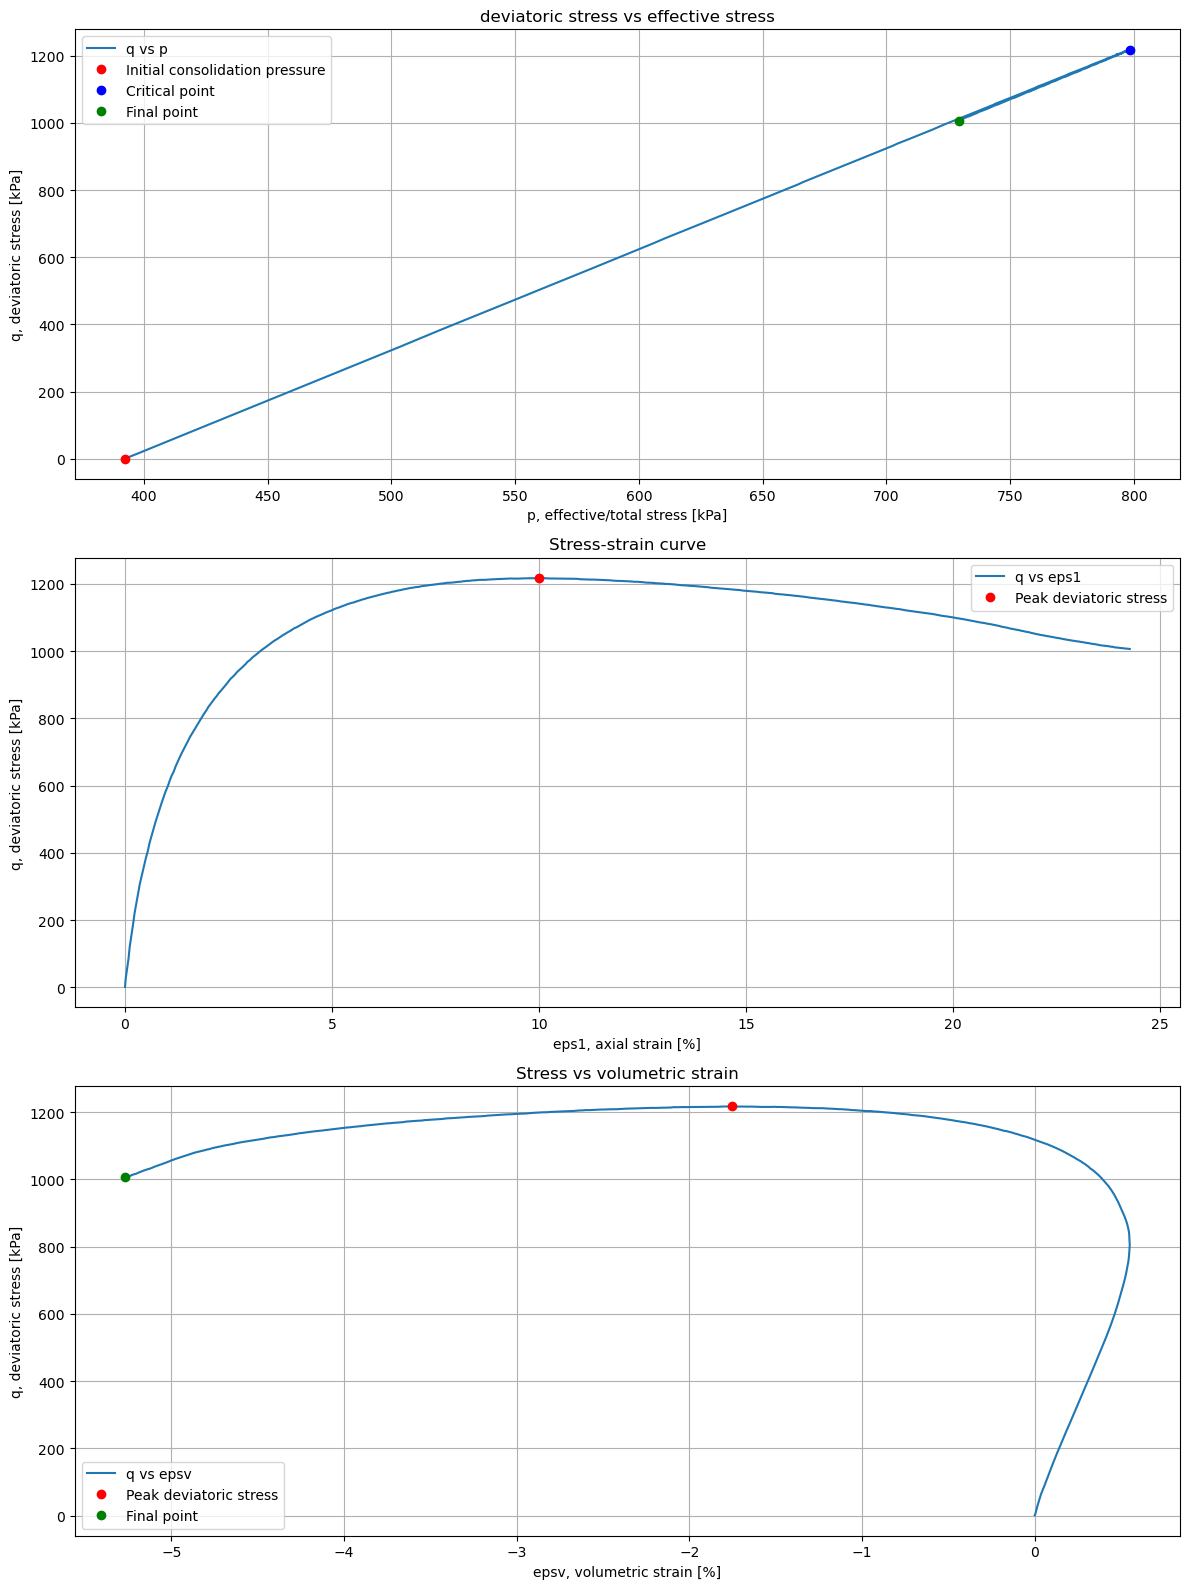

In [10]:
maximum_q, maximum_q_id, peak_eps1, peak_epsv, p0 = important_values(data)

fig = [plt.figure(figsize=(12, 16))]

ax1 = plt.subplot(3, 1, 1)
ax1.plot(data["p"], data["q"], label='q vs p')
ax1.plot(p0, data.loc[0, 'q'], 'ro', label='Initial consolidation pressure')
ax1.plot(data["p"].iloc[maximum_q_id], maximum_q, 'bo', label='Critical point')
ax1.plot(data["p"].iloc[-1], data["q"].iloc[-1], 'go', label='Final point')
ax1.set_xlabel('p, effective/total stress [kPa]')
ax1.set_ylabel('q, deviatoric stress [kPa]')
ax1.legend()
ax1.set_title('deviatoric stress vs effective stress')
ax1.grid()

ax2 = plt.subplot(3, 1, 2)
ax2.plot
ax2.plot(data['eps1'], data['q'], label='q vs eps1')
ax2.plot(peak_eps1, maximum_q, 'ro', label='Peak deviatoric stress')
ax2.set_xlabel('eps1, axial strain [%]')
ax2.set_ylabel('q, deviatoric stress [kPa]')
ax2.legend()
ax2.set_title('Stress-strain curve')
ax2.grid()

ax3 = plt.subplot(3, 1, 3)
ax3.plot(data['epsv'], data['q'], label='q vs epsv')
ax3.plot(peak_epsv, maximum_q, 'ro', label='Peak deviatoric stress')
ax3.plot(data['epsv'].iloc[-1], data['q'].iloc[-1], 'go', label='Final point')
ax3.set_title('Stress vs volumetric strain')
ax3.set_xlabel('epsv, volumetric strain [%]')
ax3.set_ylabel('q, deviatoric stress [kPa]')
ax3.legend()
ax3.grid()

plt.tight_layout()

Text(0, 0.5, 'q, deviatoric stress [kPa]')

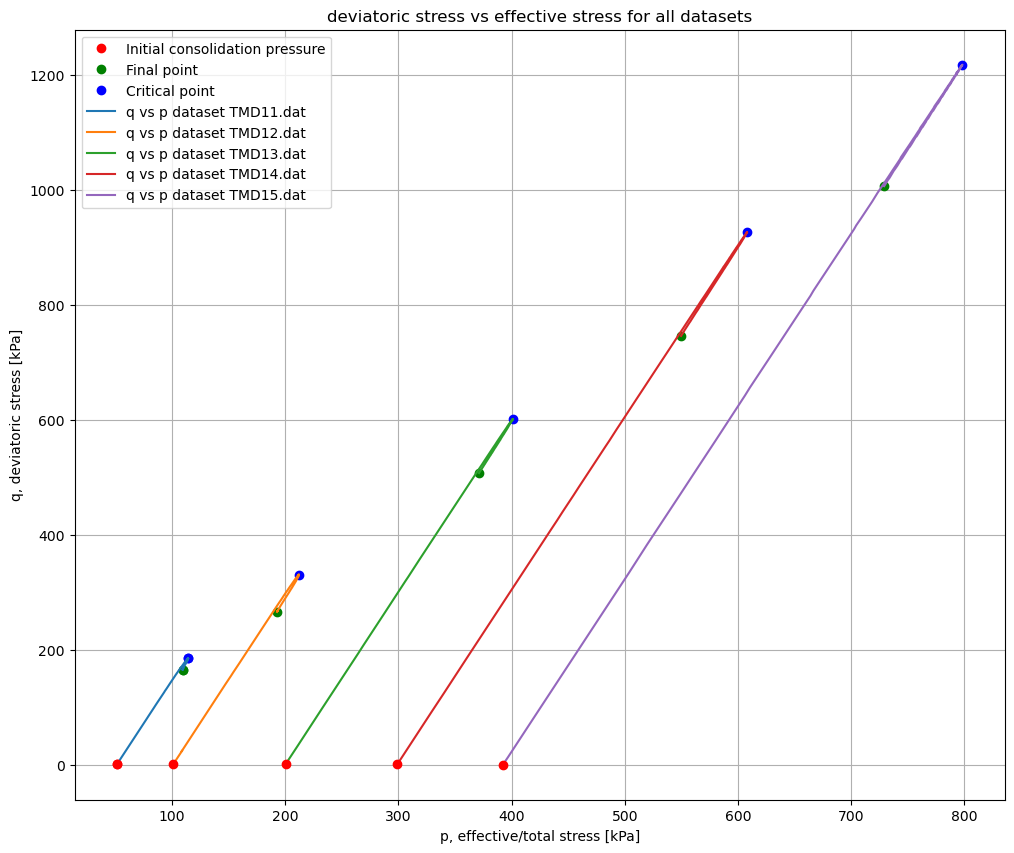

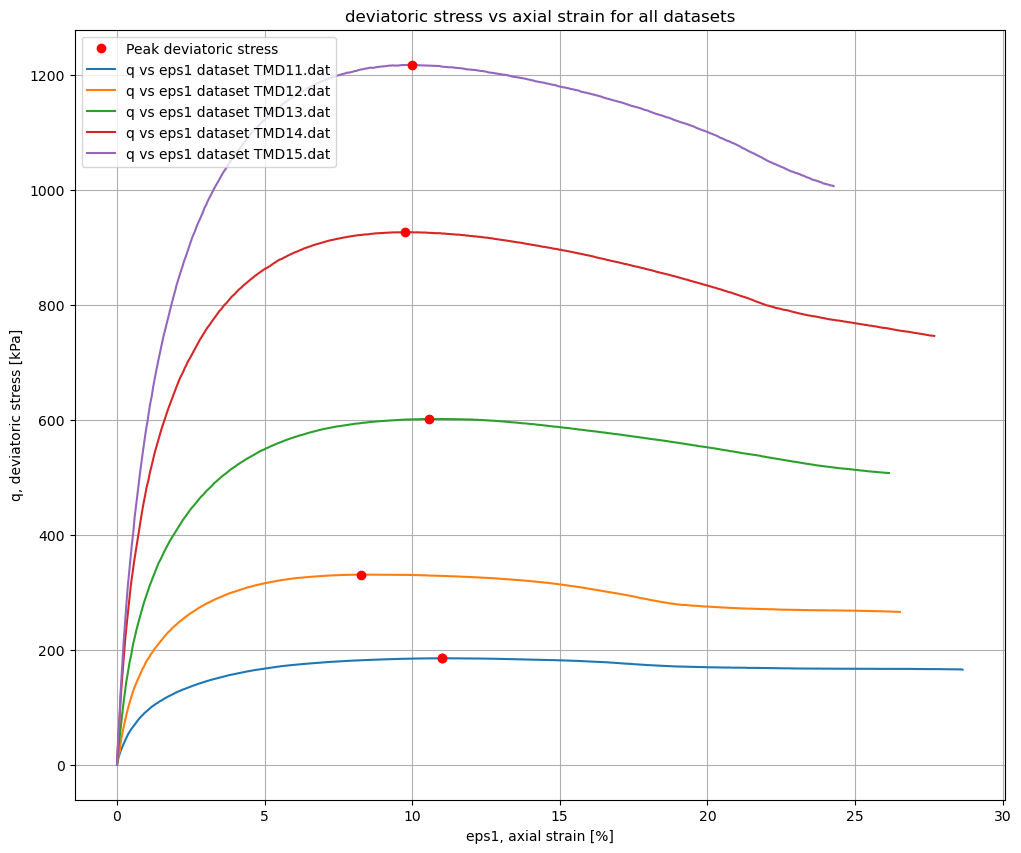

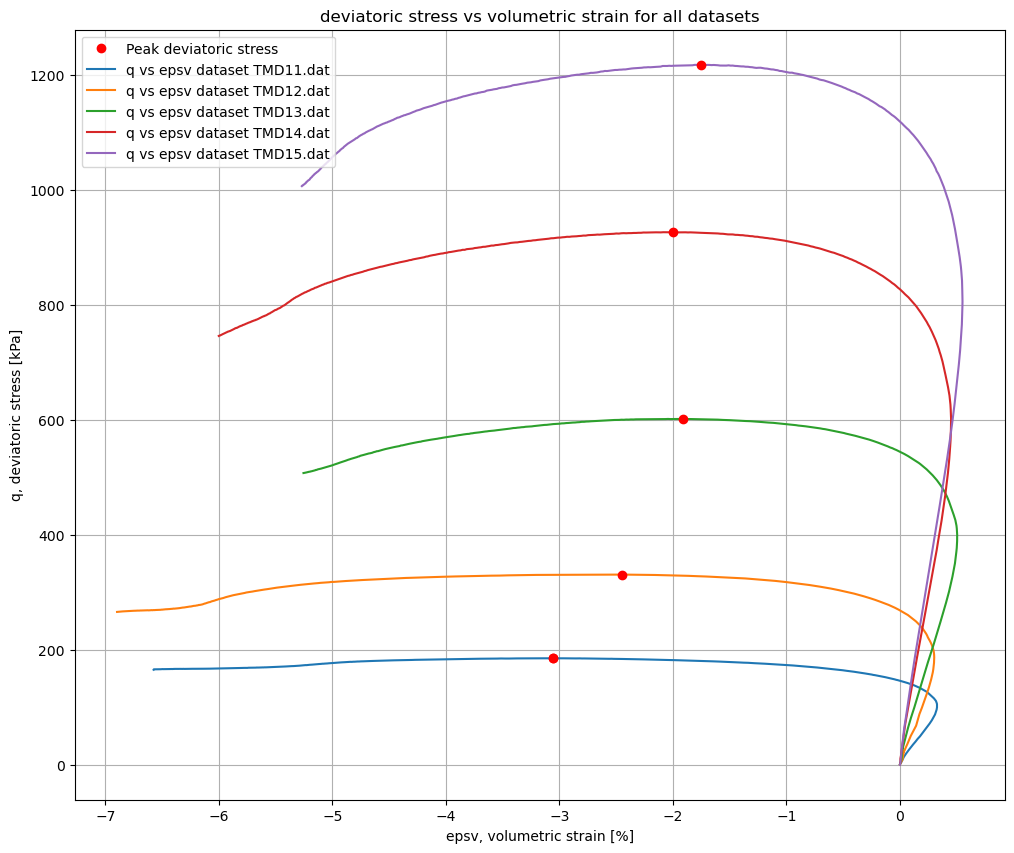

In [11]:
for index, i in enumerate(list1):
    data = load_data(i)
    maximum_q, maximum_q_id, peak_eps1, peak_epsv, p0 = important_values(data)

    if index == 0:
        plt.figure(figsize=(12, 10))
        plt.plot(p0, data.loc[0, 'q'], 'ro', label='Initial consolidation pressure')
        plt.plot(data["p"].iloc[-1], data["q"].iloc[-1], 'go', label='Final point')
        plt.plot(data["p"].iloc[maximum_q_id], maximum_q, 'bo', label='Critical point')
        
    plt.plot(data["p"].iloc[maximum_q_id], maximum_q, 'bo')
    plt.plot(data["p"].iloc[-1], data["q"].iloc[-1], 'go')
    plt.plot(data["p"], data["q"], label=f'q vs p dataset {i}')
    plt.plot(p0, data.loc[0, 'q'], 'ro')

plt.legend(loc='upper left')
plt.grid()
plt.title('deviatoric stress vs effective stress for all datasets')
plt.xlabel('p, effective/total stress [kPa]')
plt.ylabel('q, deviatoric stress [kPa]')

for index, i in enumerate(list1):
    data = load_data(i)
    maximum_q, maximum_q_id, peak_eps1, peak_epsv, p0 = important_values(data)

    if index == 0:
        plt.figure(figsize=(12, 10))
        plt.plot(peak_eps1, maximum_q, 'ro', label='Peak deviatoric stress')
        

    plt.plot(data['eps1'], data['q'], label=f'q vs eps1 dataset {i}')
    plt.plot(peak_eps1, maximum_q, 'ro')

plt.legend(loc='upper left')
plt.grid()
plt.title('deviatoric stress vs axial strain for all datasets')
plt.xlabel('eps1, axial strain [%]')
plt.ylabel('q, deviatoric stress [kPa]') 


for index, i in enumerate(list1):
    data = load_data(i)
    maximum_q, maximum_q_id, peak_eps1, peak_epsv, p0 = important_values(data)

    if index == 0:
        plt.figure(figsize=(12, 10))
        plt.plot(peak_epsv, maximum_q, 'ro', label='Peak deviatoric stress')
        

    plt.plot(data['epsv'], data['q'], label=f'q vs epsv dataset {i}')
    plt.plot(peak_epsv, maximum_q, 'ro')

plt.legend(loc='upper left')
plt.grid()
plt.title('deviatoric stress vs volumetric strain for all datasets')
plt.xlabel('epsv, volumetric strain [%]')
plt.ylabel('q, deviatoric stress [kPa]') 

# sub-task I and II

In [12]:
def load_data2(file):
    headers = ["eps1", "u", "sigma3", "sigma3_", "sigma1", "sigma1_", "p", "q"]
    data = pd.read_csv(file, sep=r"\s+", engine="python", skiprows=2, header=None)
    data = data.dropna(axis=1, how='all')
    data = data.iloc[:, :8]
    data.columns = headers
    return data

In [13]:
data = load_data2("TMU2.dat")
print(data.head())

    eps1        u   sigma3  sigma3_   sigma1  sigma1_         p      q
0  0.000  198.810  396.290  197.480  399.163  200.353  198.4377  2.873
1  0.000  198.946  396.428  197.482  399.474  200.528  198.4973  3.046
2  0.000  199.332  396.419  197.087  400.472  201.140  198.4380  4.053
3  0.001  199.835  396.391  196.556  401.700  201.865  198.3257  5.309
4  0.002  200.262  396.254  195.992  402.819  202.557  198.1803  6.565


In [14]:
print(data["eps1"].min(), data["eps1"].max())

#checking to see strains

0.0 3.2731


In [15]:
def pprime(data):
    data['p_'] = data["p"] - data["u"]
    return data['p_']

In [16]:
def important_values2(data):
    maximum_q = data['q'].max()
    maximum_q_id = data['q'].idxmax()
    peak_eps1 = data.loc[maximum_q_id, 'eps1']
    peak_u = data['u'].max()
    peak_u_id = data['u'].idxmax()
    p0 = data["p_"].iloc[0]
    return maximum_q, maximum_q_id, peak_eps1, peak_u, peak_u_id, p0

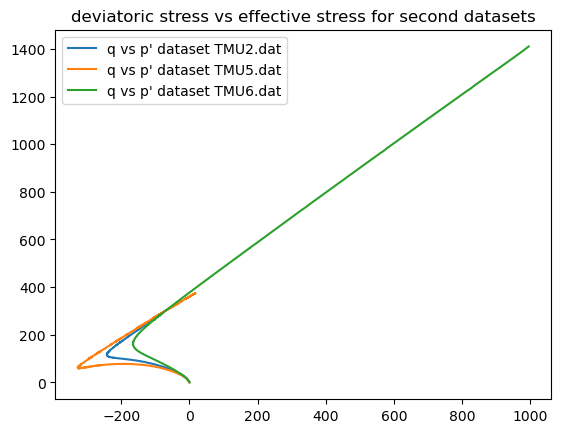

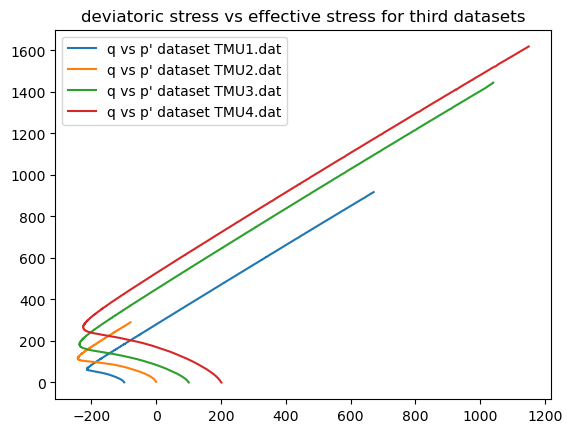

In [17]:
for i in list2:
    data = load_data2(i)
    data['p_'] = pprime(data)
    plt.plot(data['p_'], data['q'], label=f'q vs p\' dataset {i}')
    plt.legend(loc='upper left')
plt.title('deviatoric stress vs effective stress for second datasets')
plt.figure()
for i in list3:
    data = load_data2(i)
    data['p_'] = pprime(data)
    plt.plot(data['p_'], data['q'], label=f'q vs p\' dataset {i}')
    plt.legend(loc='upper left')
plt.title('deviatoric stress vs effective stress for third datasets');

8.5004


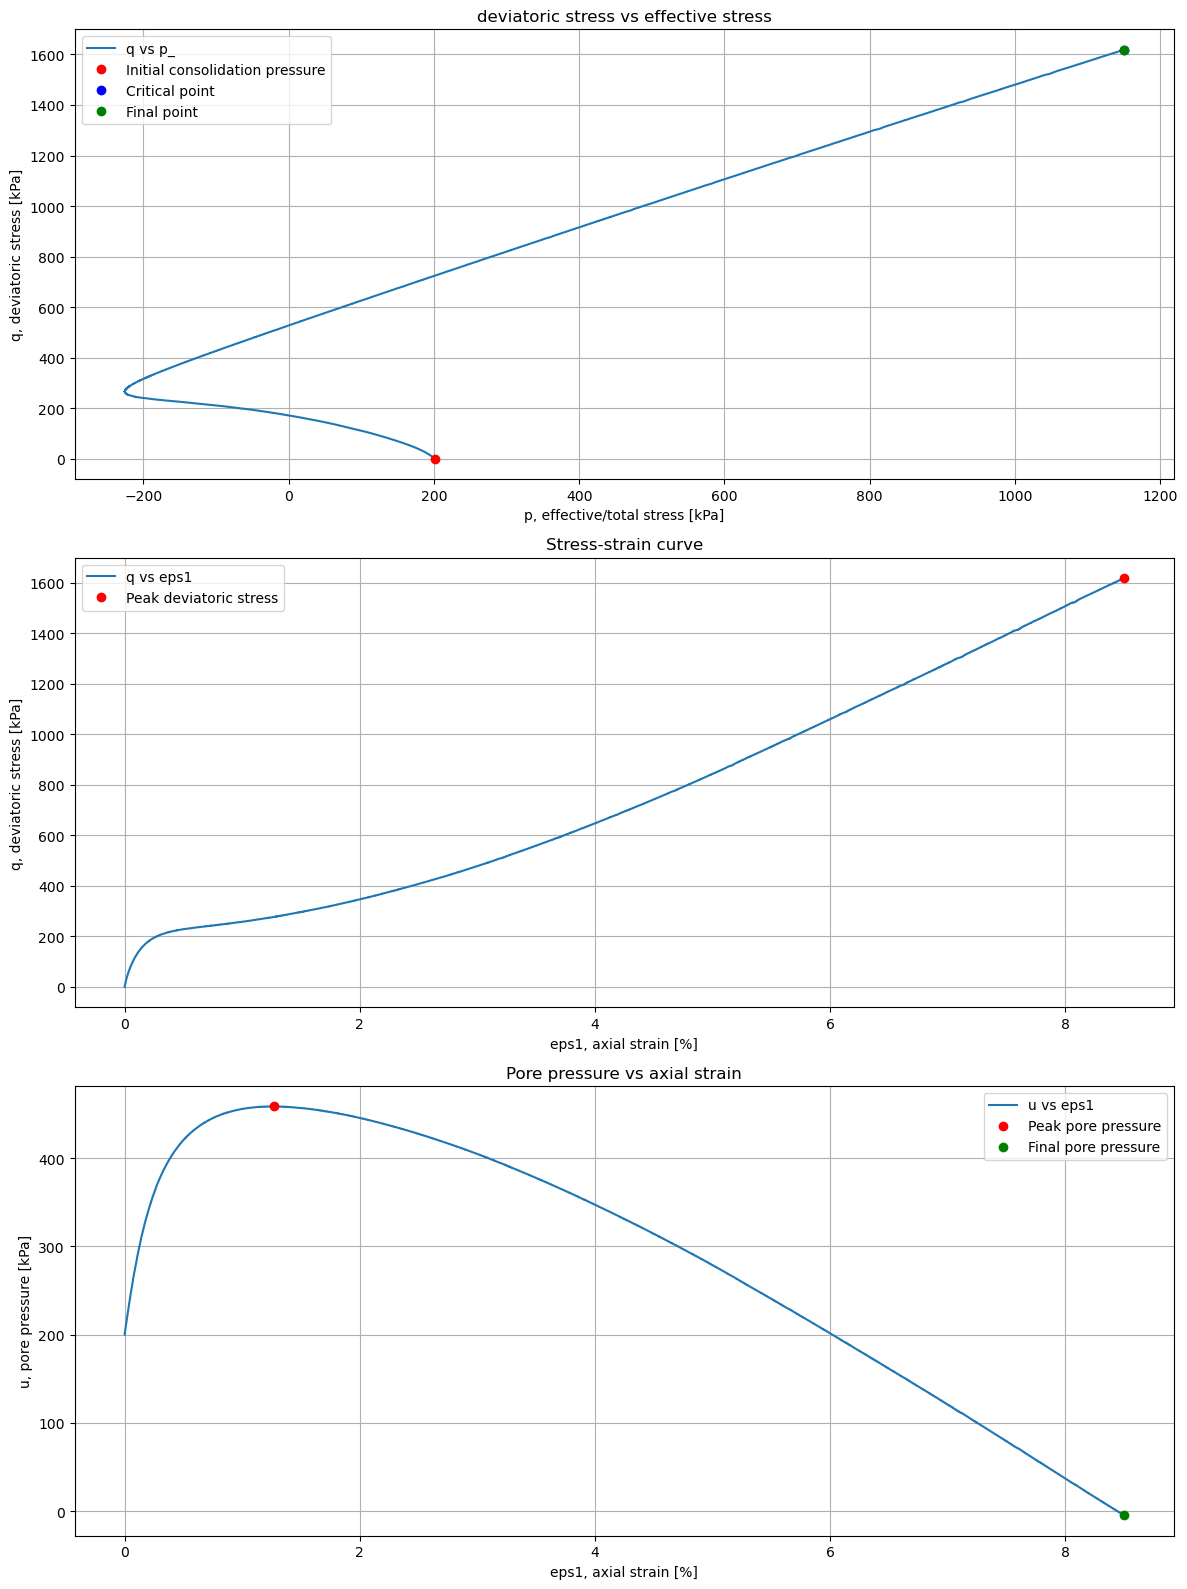

In [18]:
maximum_q, maximum_q_id, peak_eps1, peak_u, peak_u_id, p0 = important_values2(data)
print(peak_eps1)
fig = [plt.figure(figsize=(12, 16))]

ax1 = plt.subplot(3, 1, 1)
ax1.plot(data["p_"], data["q"], label='q vs p_')
ax1.plot(p0, data.loc[0, 'q'], 'ro', label='Initial consolidation pressure')
ax1.plot(data["p_"].iloc[maximum_q_id], maximum_q, 'bo', label='Critical point')
ax1.plot(data["p_"].iloc[-1], data["q"].iloc[-1], 'go', label='Final point')
ax1.set_xlabel('p, effective/total stress [kPa]')
ax1.set_ylabel('q, deviatoric stress [kPa]')
ax1.legend()
ax1.set_title('deviatoric stress vs effective stress')
ax1.grid()

ax2 = plt.subplot(3, 1, 2)
ax2.plot(data['eps1'], data['q'], label='q vs eps1')
ax2.plot(peak_eps1, maximum_q, 'ro', label='Peak deviatoric stress')
ax2.set_xlabel('eps1, axial strain [%]')
ax2.set_ylabel('q, deviatoric stress [kPa]')
ax2.legend()
ax2.set_title('Stress-strain curve')
ax2.grid()

ax3 = plt.subplot(3, 1, 3)
ax3.plot(data['eps1'], data['u'], label='u vs eps1')
ax3.plot(data["eps1"].iloc[peak_u_id], peak_u, 'ro', label='Peak pore pressure')
ax3.plot(data['eps1'].iloc[-1], data['u'].iloc[-1], 'go', label='Final pore pressure')
ax3.set_title('Pore pressure vs axial strain')
ax3.set_xlabel('eps1, axial strain [%]')
ax3.set_ylabel('u, pore pressure [kPa]')
ax3.legend()
ax3.grid()

plt.tight_layout()

Text(0, 0.5, 'u, pore pressure [kPa]')

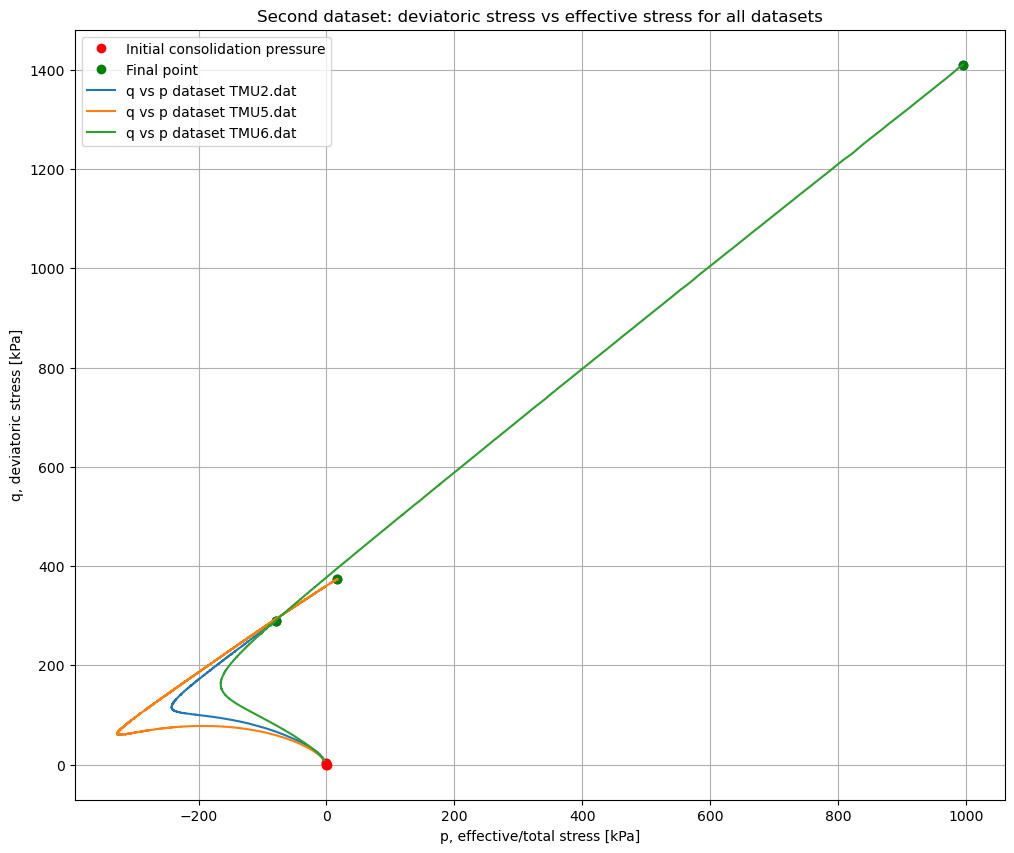

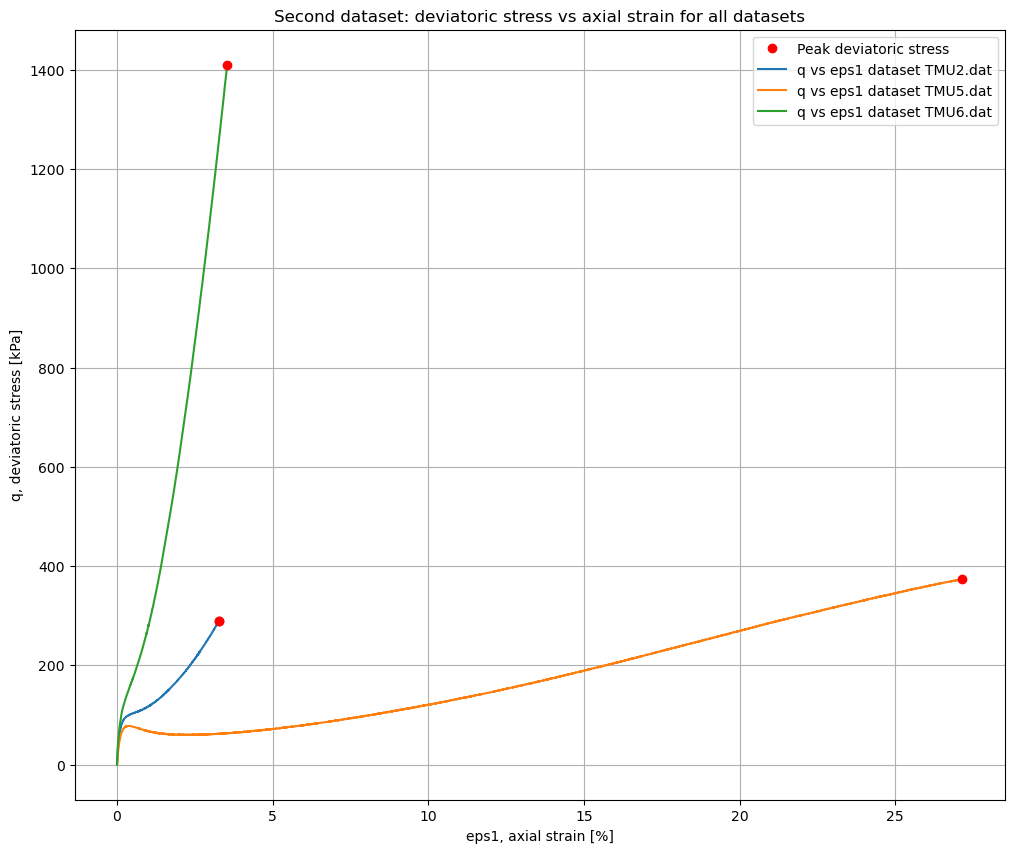

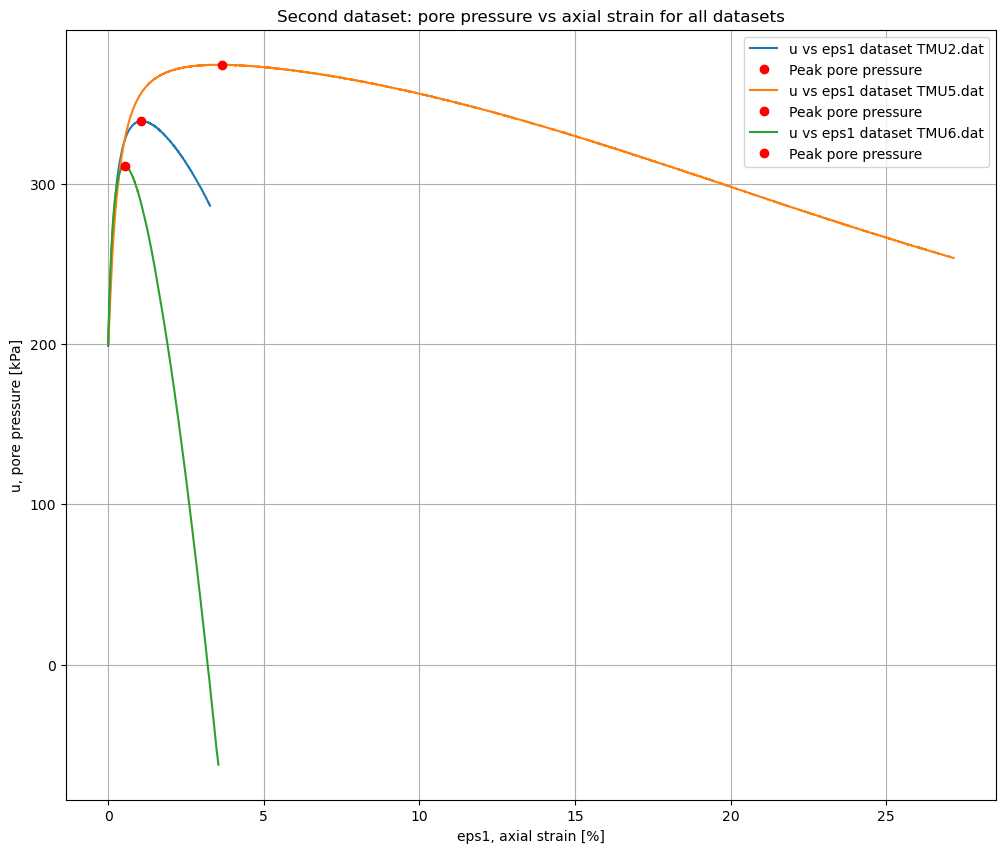

In [19]:
for index, i in enumerate(list2):
    data = load_data2(i)
    pprime(data)
    maximum_q, maximum_q_id, peak_eps1, peak_u, peak_u_id, p0 = important_values2(data)

    if index == 0:
        plt.figure(figsize=(12, 10))
        plt.plot(p0, data.loc[0, 'q'], 'ro', label='Initial consolidation pressure')
        plt.plot(data["p_"].iloc[-1], data["q"].iloc[-1], 'go', label='Final point')        
    plt.plot(data["p_"].iloc[maximum_q_id], maximum_q, 'bo')
    plt.plot(data["p_"].iloc[-1], data["q"].iloc[-1], 'go')
    plt.plot(data["p_"], data["q"], label=f'q vs p dataset {i}')
    plt.plot(p0, data.loc[0, 'q'], 'ro')

plt.legend(loc='upper left')
plt.grid()
plt.title('Second dataset: deviatoric stress vs effective stress for all datasets')
plt.xlabel('p, effective/total stress [kPa]')
plt.ylabel('q, deviatoric stress [kPa]')

for index, i in enumerate(list2):
    data = load_data2(i)
    pprime(data)
    maximum_q, maximum_q_id, peak_eps1, peak_u, peak_u_id, p0 = important_values2(data)

    if index == 0:
        plt.figure(figsize=(12, 10))
        plt.plot(peak_eps1, maximum_q, 'ro', label='Peak deviatoric stress')
        

    plt.plot(data['eps1'], data['q'], label=f'q vs eps1 dataset {i}')
    plt.plot(peak_eps1, maximum_q, 'ro')

plt.legend(loc='upper right')
plt.grid()
plt.title('Second dataset: deviatoric stress vs axial strain for all datasets')
plt.xlabel('eps1, axial strain [%]')
plt.ylabel('q, deviatoric stress [kPa]') 


for index, i in enumerate(list2):
    data = load_data2(i)
    pprime(data)
    maximum_q, maximum_q_id, peak_eps1, peak_u, peak_u_id, p0 = important_values2(data)

    if index == 0:
        plt.figure(figsize=(12, 10))

    plt.plot(data['eps1'], data['u'], label=f'u vs eps1 dataset {i}')
    plt.plot(data['eps1'].iloc[peak_u_id], peak_u, 'ro', label='Peak pore pressure')

plt.legend(loc='upper right')
plt.grid()
plt.title('Second dataset: pore pressure vs axial strain for all datasets')
plt.xlabel('eps1, axial strain [%]')
plt.ylabel('u, pore pressure [kPa]') 

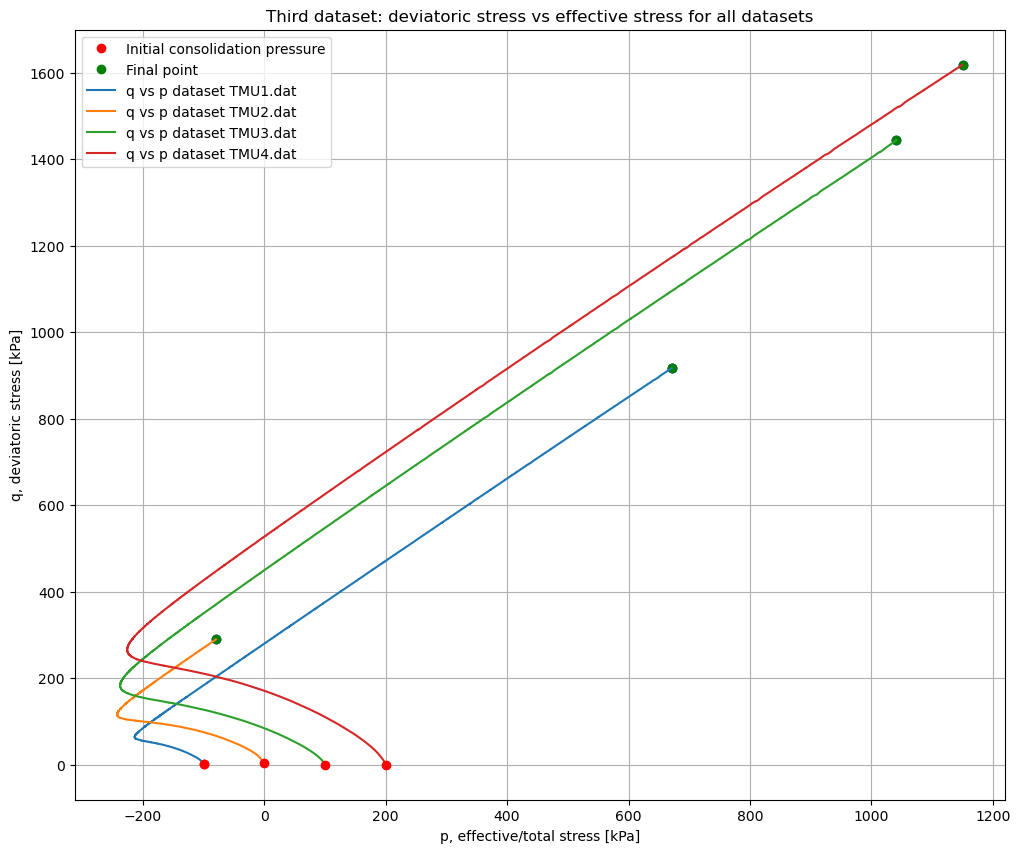

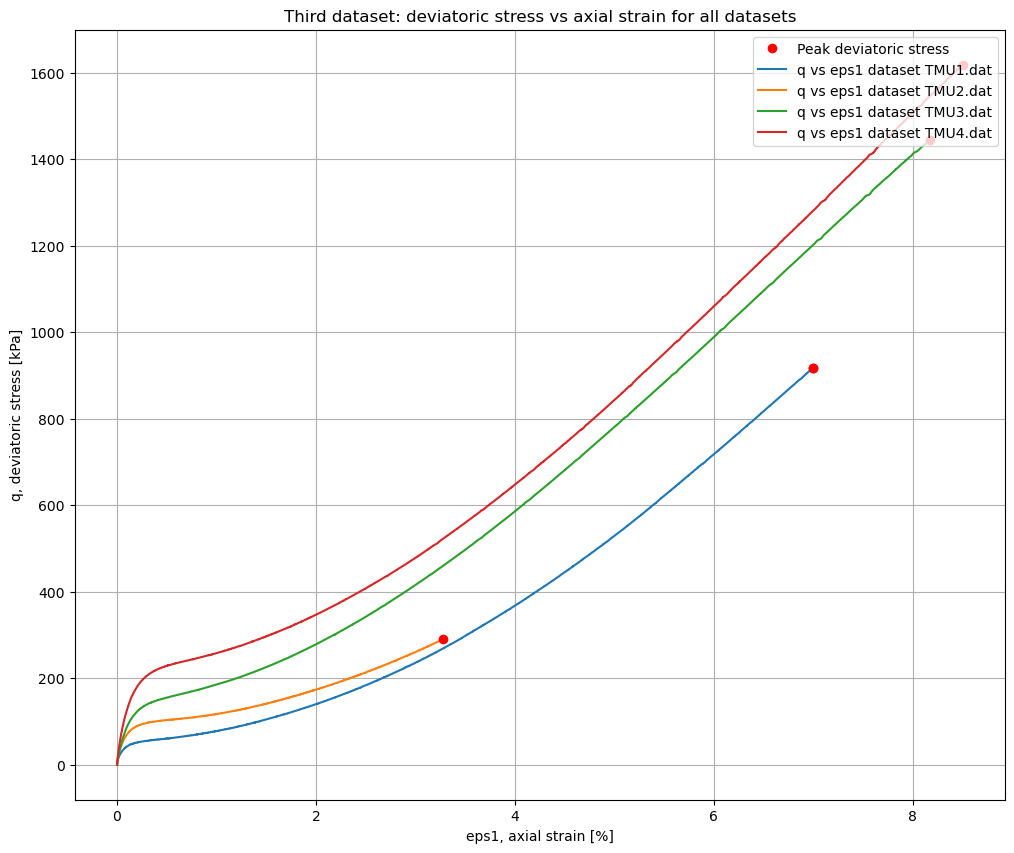

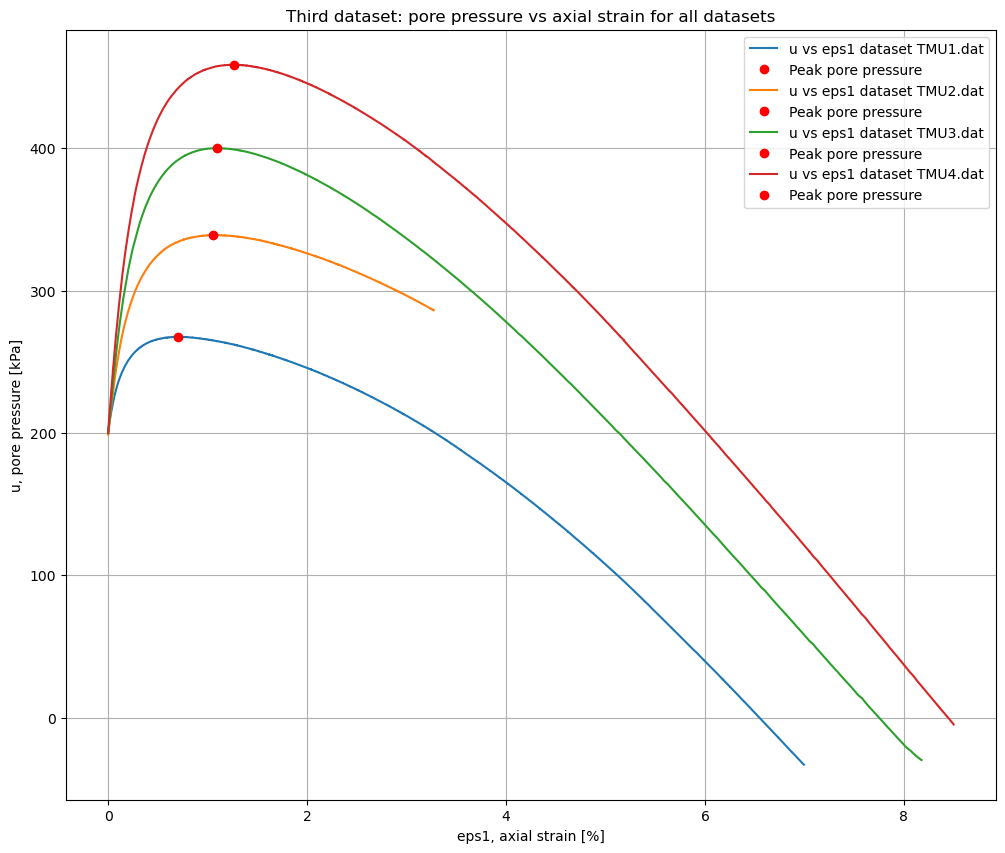

In [20]:
for index, i in enumerate(list3):
    data = load_data2(i)
    pprime(data)
    maximum_q, maximum_q_id, peak_eps1, peak_u, peak_u_id, p0 = important_values2(data)

    if index == 0:
        plt.figure(figsize=(12, 10))
        plt.plot(p0, data.loc[0, 'q'], 'ro', label='Initial consolidation pressure')
        plt.plot(data["p_"].iloc[-1], data["q"].iloc[-1], 'go', label='Final point')        
    plt.plot(data["p_"].iloc[maximum_q_id], maximum_q, 'bo')
    plt.plot(data["p_"].iloc[-1], data["q"].iloc[-1], 'go')
    plt.plot(data["p_"], data["q"], label=f'q vs p dataset {i}')
    plt.plot(p0, data.loc[0, 'q'], 'ro')

plt.legend(loc='upper left')
plt.grid()
plt.title('Third dataset: deviatoric stress vs effective stress for all datasets')
plt.xlabel('p, effective/total stress [kPa]')
plt.ylabel('q, deviatoric stress [kPa]')

for index, i in enumerate(list3):
    data = load_data2(i)
    pprime(data)
    maximum_q, maximum_q_id, peak_eps1, peak_u, peak_u_id, p0 = important_values2(data)

    if index == 0:
        plt.figure(figsize=(12, 10))
        plt.plot(peak_eps1, maximum_q, 'ro', label='Peak deviatoric stress')
        

    plt.plot(data['eps1'], data['q'], label=f'q vs eps1 dataset {i}')
    plt.plot(peak_eps1, maximum_q, 'ro')

plt.legend(loc='upper right')
plt.grid()
plt.title('Third dataset: deviatoric stress vs axial strain for all datasets')
plt.xlabel('eps1, axial strain [%]')
plt.ylabel('q, deviatoric stress [kPa]') 


for index, i in enumerate(list3):
    data = load_data2(i)
    pprime(data)
    maximum_q, maximum_q_id, peak_eps1, peak_u, peak_u_id, p0 = important_values2(data)

    if index == 0:
        plt.figure(figsize=(12, 10))

    plt.plot(data['eps1'], data['u'], label=f'u vs eps1 dataset {i}')
    plt.plot(data['eps1'].iloc[peak_u_id], peak_u, 'ro', label='Peak pore pressure')

plt.legend(loc='upper right')
plt.grid()
plt.title('Third dataset: pore pressure vs axial strain for all datasets')
plt.xlabel('eps1, axial strain [%]')
plt.ylabel('u, pore pressure [kPa]');

TMU2.dat: Young's modulus = 262.01 kPa
TMU5.dat: Young's modulus = 315.02 kPa
TMU6.dat: Young's modulus = 397.01 kPa
TMU1.dat: Young's modulus = 114.65 kPa
TMU2.dat: Young's modulus = 262.01 kPa
TMU3.dat: Young's modulus = 355.95 kPa
TMU4.dat: Young's modulus = 652.67 kPa


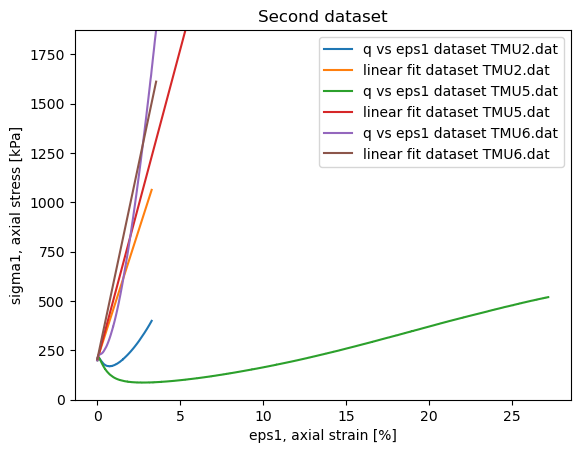

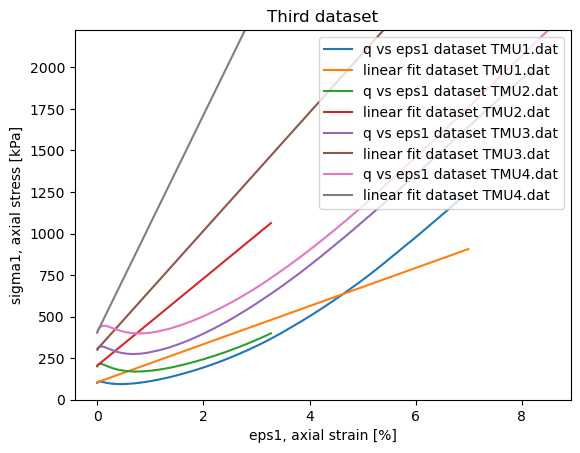

In [21]:
for i in list2:
    data = load_data2(i)
    pprime(data)
    elastic_range = data[data["eps1"] <= 0.05]

    slope, intercept, *_ = linregress(
        elastic_range["eps1"],
        elastic_range["sigma1_"]
    )

    E = slope
    print(f"{i}: Young's modulus = {E:.2f} kPa")
    plt.plot(data['eps1'], data['sigma1_'], label=f'q vs eps1 dataset {i}')
    plt.plot(data['eps1'], slope * data['eps1'] + intercept, label=f'linear fit dataset {i} ')
plt.ylim(0, data['sigma1_'].max())
plt.xlabel('eps1, axial strain [%]')
plt.ylabel('sigma1, axial stress [kPa]')
plt.legend(loc='upper right')
plt.title('Second dataset')
plt.figure()
for i in list3:
    data = load_data2(i)
    pprime(data)
    elastic_range = data[data["eps1"] <= 0.05]

    slope, intercept, *_ = linregress(
        elastic_range["eps1"],
        elastic_range["sigma1_"]
    )

    E = slope
    print(f"{i}: Young's modulus = {E:.2f} kPa")
    plt.plot(data['eps1'], data['sigma1_'], label=f'q vs eps1 dataset {i}')
    plt.plot(data['eps1'], slope * data['eps1'] + intercept, label=f'linear fit dataset {i} ')
plt.ylim(0, data['sigma1_'].max())
plt.xlabel('eps1, axial strain [%]')
plt.ylabel('sigma1, axial stress [kPa]')
plt.legend(loc='upper right')
plt.title('Third dataset');

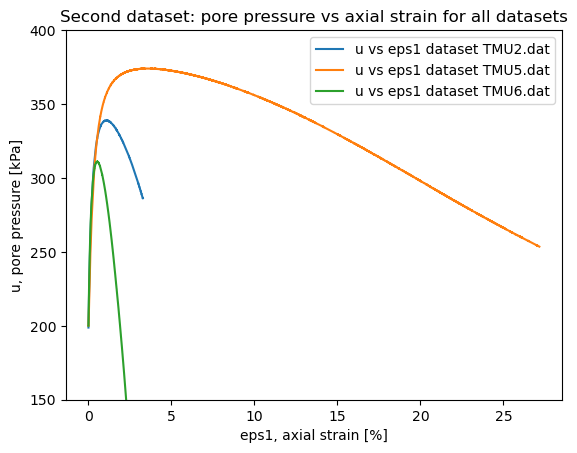

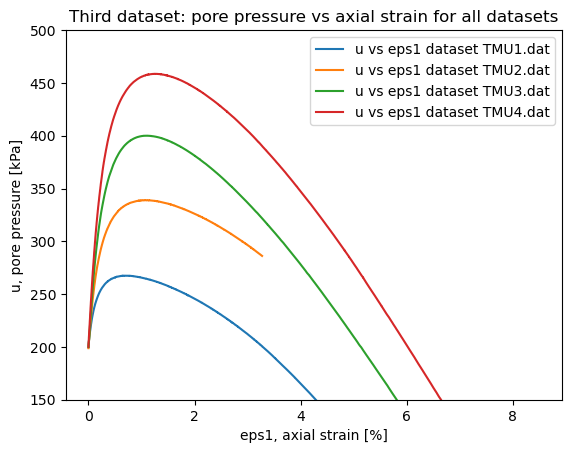

In [22]:
for i in list2:
    data = load_data2(i)
    data['p_'] = pprime(data)
    plt.plot(data['eps1'], data['u'], label=f'u vs eps1 dataset {i}')    
plt.ylabel('u, pore pressure [kPa]')
plt.xlabel('eps1, axial strain [%]')
plt.ylim(150, 400)
plt.legend(loc='upper right')
plt.title('Second dataset: pore pressure vs axial strain for all datasets')
plt.figure()

for i in list3:
    data = load_data2(i)
    data['p_'] = pprime(data)
    plt.plot(data['eps1'], data['u'], label=f'u vs eps1 dataset {i}')
plt.ylabel('u, pore pressure [kPa]')
plt.xlabel('eps1, axial strain [%]')
plt.ylim(150, 500)
plt.legend(loc='upper right')
plt.title('Third dataset: pore pressure vs axial strain for all datasets');

# Clay

In [23]:
list4 = ["M1.dat","M2.dat","M3.dat","M4.dat","M5.dat"]  #OCR = 1
list5 = ["M6.dat", "M7.dat", "M8.dat", "M9.dat"]  # varition of strain rate
list6 = ["M2.dat","M10.dat","M11.dat","M12.dat"]  # Variation in OCR

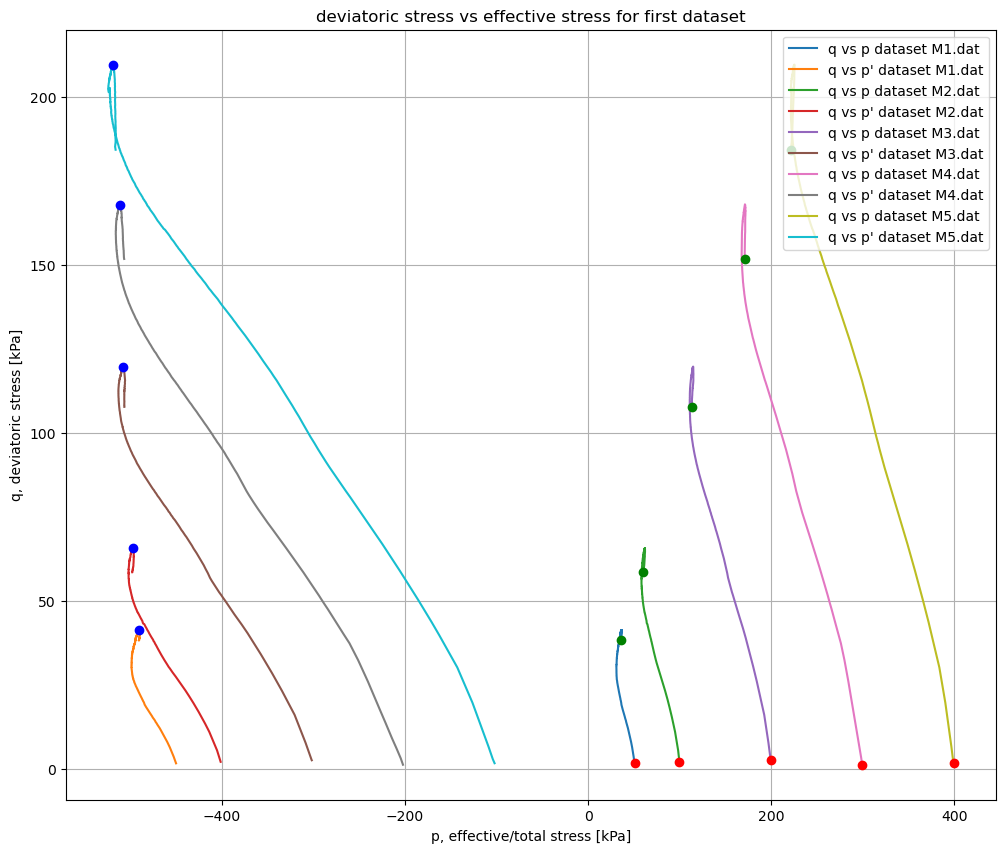

In [24]:
plt.figure(figsize=(12, 10))
M = np.zeros(len(list4))

for idx, i in enumerate(list4):
    data = load_data2(i)
    data["p_"] = pprime(data)  # make p_ before important_values2
    maximum_q, maximum_q_id, peak_eps1, peak_u, peak_u_id, p0 = important_values2(data)

    plt.plot(data["p"], data["q"], label=f"q vs p dataset {i}")
    plt.plot(data["p"].iloc[0], data["q"].iloc[0], "ro")
    plt.plot(data["p"].iloc[-1], data["q"].iloc[-1], "go")

    p_eff = data["p"] - data["u"]
    plt.plot(p_eff, data["q"], label=f"q vs p' dataset {i}")

    M[idx] = maximum_q / p_eff.iloc[maximum_q_id]   # integer index
    plt.plot(p_eff.iloc[maximum_q_id], maximum_q, "bo")

plt.grid()
plt.title("deviatoric stress vs effective stress for first dataset")
plt.xlabel("p, effective/total stress [kPa]")
plt.ylabel("q, deviatoric stress [kPa]")
plt.legend(loc="upper right");

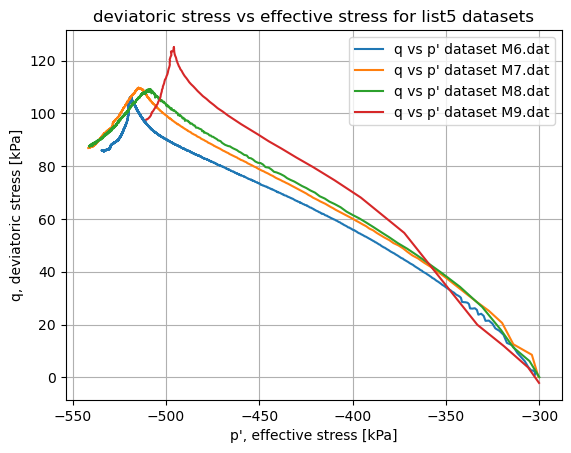

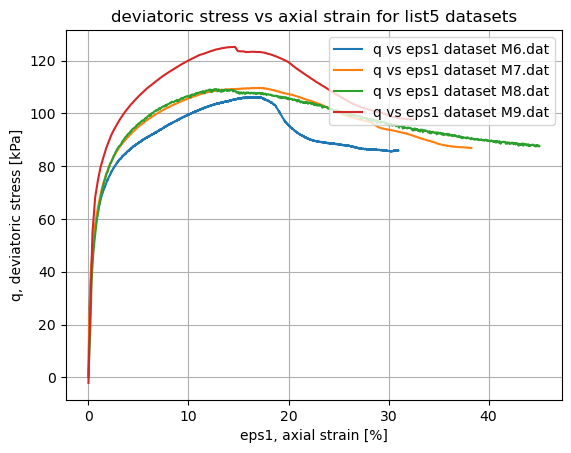

In [25]:
for i in list5:
    data = load_data2(i)
    data['p_'] = pprime(data)
    plt.plot(data['p_'], data['q'], label=f'q vs p\' dataset {i}')

plt.xlabel('p\', effective stress [kPa]')
plt.ylabel('q, deviatoric stress [kPa]')
plt.title('deviatoric stress vs effective stress for list5 datasets')
plt.legend(loc='upper right')
plt.grid()
plt.figure()
for i in list5:
    data = load_data2(i)
    data['p_'] = pprime(data)
    plt.plot(data['eps1'], data['q'], label=f'q vs eps1 dataset {i}')
plt.xlabel('eps1, axial strain [%]')
plt.ylabel('q, deviatoric stress [kPa]')
plt.title('deviatoric stress vs axial strain for list5 datasets')
plt.legend(loc='upper right')
plt.grid();

In [26]:
OCR6 = np.array([1, 2, 4, 8])
su_sigmaeff =0.22*OCR6**0.8



Results for OCR=1 Tests (M1-M5):
Test   p'₀ (kPa)    σ'₃₀ (kPa)   q_max (kPa)  sᵤ (kPa)     E₀ (MPa)    
------------------------------------------------------------------------------------------
M1          50.71       50.15       41.31       20.65        8.51
M2          99.70       98.99       65.67       32.84         nan
M3         199.45      198.59      119.65       59.82         nan
M4         299.22      298.80      167.85       83.93       17.03
M5         399.15      398.58      209.46      104.73         nan


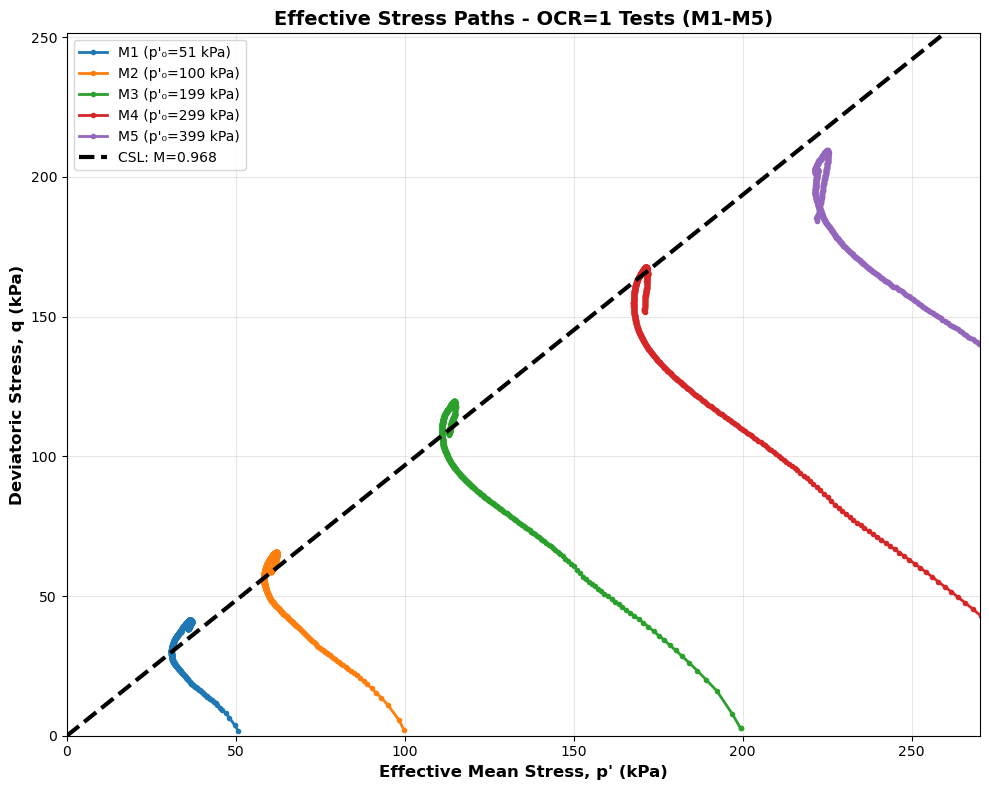


FRICTION ANGLE ANALYSIS
Critical State Line Slope (M): 0.9678
Material Friction Angle (φ'): 24.63°
sin(φ'): 0.4167



In [27]:
ocr1_tests = ['M1', 'M2', 'M3', 'M4', 'M5']
results_ocr1 = {}

for test_name in ocr1_tests:
    df = load_data2(f"{test_name}.dat")

    p0_prime = df['p'].iloc[0]
    sigma3_prime_0 = df["sigma3'"].iloc[0] if "sigma3'" in df.columns else df['sigma3'].iloc[0] - df['u'].iloc[0]
    
    q_max = df['q'].max()
    q_max_idx = df['q'].idxmax()
    
    su = q_max / 2
    
    p_prime_at_peak = df['p'].iloc[q_max_idx]
    
    strain_limit = 0.1
    initial_data = df[df['eps1'] <= strain_limit]
    if len(initial_data) > 5:
        slope, intercept, r_value, _, _ = stats.linregress(initial_data['eps1'], initial_data['q'])
        E_initial = slope * 100
    else:
        E_initial = np.nan
    
    results_ocr1[test_name] = {
        'p0_prime': p0_prime,
        'sigma3_prime_0': sigma3_prime_0,
        'q_max': q_max,
        'su': su,
        'p_prime_at_peak': p_prime_at_peak,
        'E_initial': E_initial
    }

print("Results for OCR=1 Tests (M1-M5):")
print("=" * 90)
print(f"{'Test':<6} {'p\'₀ (kPa)':<12} {'σ\'₃₀ (kPa)':<12} {'q_max (kPa)':<12} {'sᵤ (kPa)':<12} {'E₀ (MPa)':<12}")
print("-" * 90)
for test, res in results_ocr1.items():
    print(f"{test:<6} {res['p0_prime']:>10.2f}  {res['sigma3_prime_0']:>10.2f}  {res['q_max']:>10.2f}  {res['su']:>10.2f}  {res['E_initial']/1000:>10.2f}")
print("=" * 90)

fig, ax = plt.subplots(figsize=(10, 8))
for test_name in ocr1_tests:
    df = load_data2(f"{test_name}.dat")
    p0 = results_ocr1[test_name]['p0_prime']
    ax.plot(df['p'], df['q'], 'o-', markersize=3, label=f"{test_name} (p\'₀={p0:.0f} kPa)", linewidth=2)

p_peaks = [results_ocr1[test]['p_prime_at_peak'] for test in ocr1_tests]
q_peaks = [results_ocr1[test]['q_max'] for test in ocr1_tests]
M = np.sum(np.array(p_peaks) * np.array(q_peaks)) / np.sum(np.array(p_peaks)**2)
p_max = max(p_peaks) * 1.2
p_line = np.linspace(0, p_max, 100)
q_line = M * p_line
ax.plot(p_line, q_line, 'k--', linewidth=3, label=f'CSL: M={M:.3f}')
sin_phi = 3*M / (6 + M)
phi_deg = np.arcsin(sin_phi) * 180 / np.pi

ax.set_xlabel("Effective Mean Stress, p' (kPa)", fontsize=12, fontweight='bold')
ax.set_ylabel("Deviatoric Stress, q (kPa)", fontsize=12, fontweight='bold')
ax.set_title("Effective Stress Paths - OCR=1 Tests (M1-M5)", fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, p_max)
ax.set_ylim(0, max(q_peaks) * 1.2)
plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print(f"FRICTION ANGLE ANALYSIS")
print(f"{'='*60}")
print(f"Critical State Line Slope (M): {M:.4f}")
print(f"Material Friction Angle (φ'): {phi_deg:.2f}°")
print(f"sin(φ'): {sin_phi:.4f}")
print(f"{'='*60}\n")

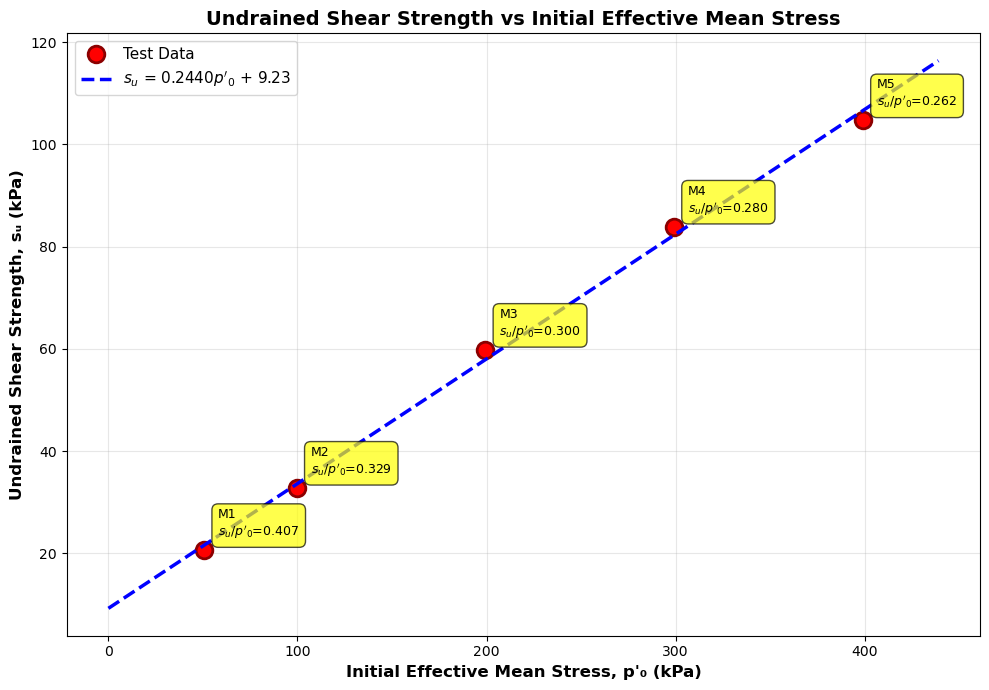


UNDRAINED SHEAR STRENGTH ANALYSIS:
Linear relationship: sᵤ = 0.2440 × p'₀ + 9.23 kPa
R² = 0.9976
Average sᵤ/p'₀ ratio: 0.3159



In [28]:

p0_prime_values = [results_ocr1[test]['p0_prime'] for test in ocr1_tests]
su_values = [results_ocr1[test]['su'] for test in ocr1_tests]


slope_su, intercept_su, r_su, _, _ = stats.linregress(p0_prime_values, su_values)

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(p0_prime_values, su_values, 'ro', markersize=12, label='Test Data', markeredgecolor='darkred', markeredgewidth=2)

p_fit = np.linspace(0, max(p0_prime_values)*1.1, 100)
su_fit = slope_su * p_fit + intercept_su
ax.plot(p_fit, su_fit, 'b--', linewidth=2.5, label=f'$s_u$ = {slope_su:.4f}$p\'_0$ + {intercept_su:.2f}')

for i, test in enumerate(ocr1_tests):
    ratio = su_values[i] / p0_prime_values[i]
    ax.annotate(f'{test}\n$s_u/p\'_0$={ratio:.3f}', 
                xy=(p0_prime_values[i], su_values[i]), 
                xytext=(10, 10), textcoords='offset points',
                fontsize=9, bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

ax.set_xlabel("Initial Effective Mean Stress, p'₀ (kPa)", fontsize=12, fontweight='bold')
ax.set_ylabel("Undrained Shear Strength, sᵤ (kPa)", fontsize=12, fontweight='bold')
ax.set_title("Undrained Shear Strength vs Initial Effective Mean Stress", fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nUNDRAINED SHEAR STRENGTH ANALYSIS:")
print(f"{'='*60}")
print(f"Linear relationship: sᵤ = {slope_su:.4f} × p'₀ + {intercept_su:.2f} kPa")
print(f"R² = {r_su**2:.4f}")
print(f"Average sᵤ/p'₀ ratio: {np.mean([su_values[i]/p0_prime_values[i] for i in range(len(ocr1_tests))]):.4f}")
print(f"{'='*60}\n")

In [29]:
strain_limit = 0.2
p_list, e_list = [], []

for t in ocr1_tests:
    df = load_data2(f"{t}.dat")
    subset = df[df['eps1'] <= strain_limit]
    if len(subset) > 5:
        slope, _, _, _, _ = stats.linregress(subset['eps1'], subset['q'])
        e0_mpa = (slope * 100) / 1000  # kPa -> MPa
        if np.isfinite(e0_mpa) and e0_mpa > 0:
            p_list.append(results_ocr1[t]['p0_prime'])
            e_list.append(e0_mpa)

if len(e_list) >= 3:
    log_p = np.log(np.array(p_list))
    log_e = np.log(np.array(e_list))
    n_exp_tmp, log_A_tmp, r_tmp, _, _ = stats.linregress(log_p, log_e)
    A_tmp = np.exp(log_A_tmp)
    print(f"  E0 = {A_tmp:.3f} * (p'0)^{n_exp_tmp:.3f} MPa, R^2={r_tmp**2:.4f}")

  E0 = 0.186 * (p'0)^0.833 MPa, R^2=0.9941


,test,p0_prime_kPa,p_end_prime_kPa,q_peak_kPa,eps1_at_q_peak_pct,q_end_kPa
0,M6,-302.160,-534.266,106.141,16.184,85.895
1,M7,-300.440,-541.610,109.704,16.947,86.874
2,M8,-299.904,-541.222,109.173,12.732,87.605
3,M9,-300.082,-510.599,125.167,14.664,97.661


Interpretation hints per test:
M6: q_peak=106.14 kPa at eps1=16.184%, contractive tendency (p' decreases), post-peak softening.
M7: q_peak=109.70 kPa at eps1=16.947%, contractive tendency (p' decreases), post-peak softening.
M8: q_peak=109.17 kPa at eps1=12.732%, contractive tendency (p' decreases), post-peak softening.
M9: q_peak=125.17 kPa at eps1=14.664%, contractive tendency (p' decreases), post-peak softening.


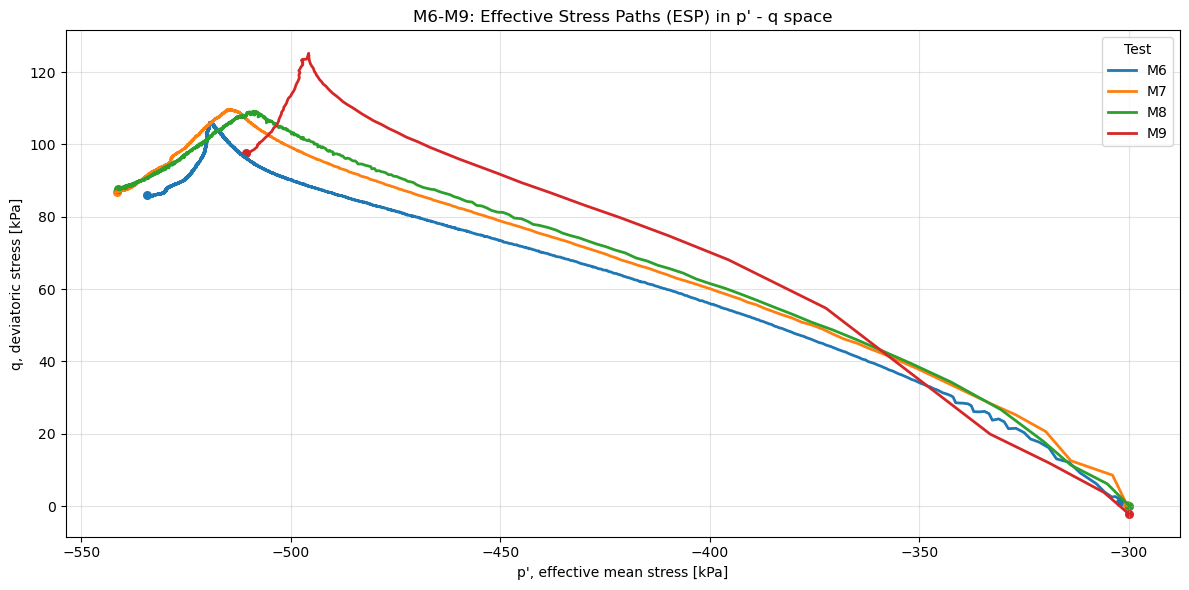

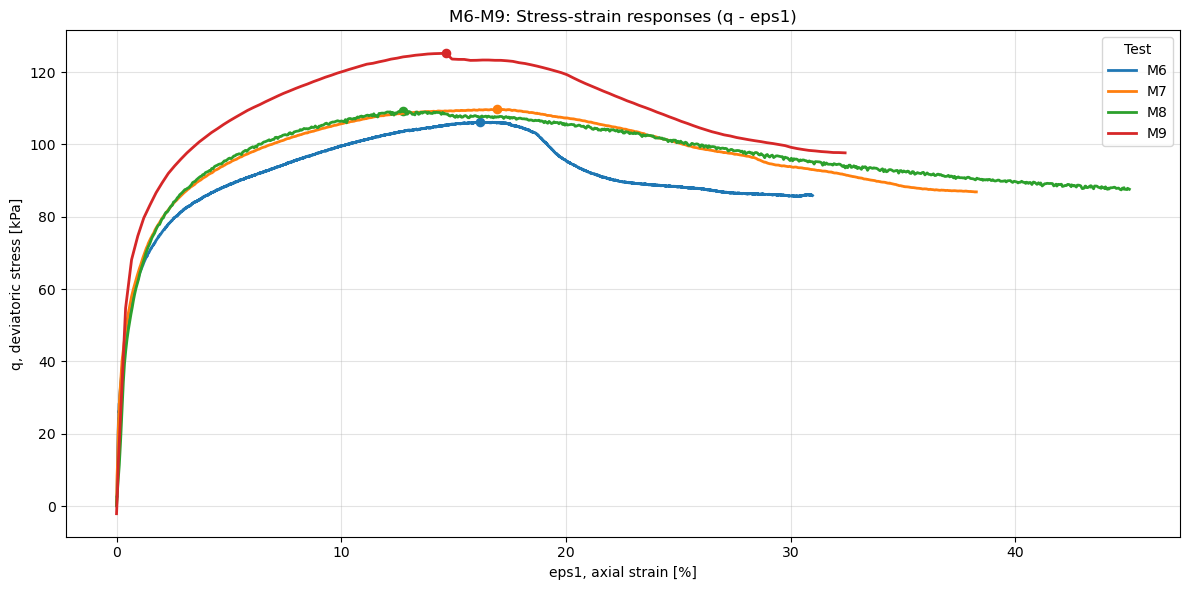

In [31]:

summary_rows = []

plt.figure(figsize=(12, 6))
for file in list5:
    data = load_data2(file).copy()
    data['p_'] = pprime(data)

    idx_peak = data['q'].idxmax()
    q_peak = data.loc[idx_peak, 'q']
    eps1_peak = data.loc[idx_peak, 'eps1']
    p0 = data['p_'].iloc[0]
    p_end = data['p_'].iloc[-1]
    q_end = data['q'].iloc[-1]

    summary_rows.append({
        'test': file.replace('.dat', ''),
        'p0_prime_kPa': p0,
        'p_end_prime_kPa': p_end,
        'q_peak_kPa': q_peak,
        'eps1_at_q_peak_pct': eps1_peak,
        'q_end_kPa': q_end
    })

    plt.plot(data['p_'], data['q'], linewidth=2, label=file.replace('.dat', ''))
    plt.scatter([p0, p_end], [data['q'].iloc[0], q_end], s=30)

plt.xlabel("p', effective mean stress [kPa]")
plt.ylabel('q, deviatoric stress [kPa]')
plt.title("M6-M9: Effective Stress Paths (ESP) in p' - q space")
plt.legend(title='Test', loc='best')
plt.grid(alpha=0.35)
plt.tight_layout()

plt.figure(figsize=(12, 6))
for file in list5:
    data = load_data2(file).copy()
    data['p_'] = pprime(data)

    idx_peak = data['q'].idxmax()
    q_peak = data.loc[idx_peak, 'q']
    eps1_peak = data.loc[idx_peak, 'eps1']

    plt.plot(data['eps1'], data['q'], linewidth=2, label=file.replace('.dat', ''))
    plt.scatter([eps1_peak], [q_peak], s=35)

plt.xlabel('eps1, axial strain [%]')
plt.ylabel('q, deviatoric stress [kPa]')
plt.title('M6-M9: Stress-strain responses (q - eps1)')
plt.legend(title='Test', loc='best')
plt.grid(alpha=0.35)
plt.tight_layout()
summary_df = pd.DataFrame(summary_rows).sort_values('test').reset_index(drop=True)
display(summary_df.round(3))

print('Interpretation hints per test:')
for _, row in summary_df.iterrows():
    volumetric_tendency = 'contractive tendency (p\' decreases)' if row['p_end_prime_kPa'] < row['p0_prime_kPa'] else 'dilative tendency (p\' stable/increases)'
    post_peak = 'post-peak softening' if row['q_end_kPa'] < 0.95 * row['q_peak_kPa'] else 'no strong softening in recorded range'
    print(f"{row['test']}: q_peak={row['q_peak_kPa']:.2f} kPa at eps1={row['eps1_at_q_peak_pct']:.3f}%, {volumetric_tendency}, {post_peak}.")